<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 10B: *Fire Damage Feature Ablation*
##### Version Number: 4.0
---
### Contents  
> *Build Models*\
> *SHAP*\
> *Set Ablation*
---
### Notes
---
### Inputs
---
### Outputs 
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import json

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split

---

###  Load Data

In [3]:
X_damage = pd.read_csv('../data/processed/X_damage.csv')
y_damage = pd.read_csv('../data/processed/y_damage.csv').squeeze()  # Load as Series
details_damage = pd.read_csv('../data/processed/details_damage.csv')

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

best_strategy = pd.read_csv('../data/processed/damage_best_strategy.csv')

with open('../data/processed/model_parameters_damage.json', 'r') as f:
    model_parameters = json.load(f)

with open('../data/processed/feature_sets.json', 'r') as f:
    feature_sets = json.load(f)

## Subset

In [4]:
reform = pd.concat([X_damage,y_damage], axis=1)
subset = subset_df(reform, 'Target_Damage', 500)

y = subset['Target_Damage']
X = subset.drop(columns='Target_Damage')

In [5]:
X_rf, y_rf = apply_balancing('RF', best_strategy, X, y)
X_xgb, y_xgb = apply_balancing('XGB', best_strategy, X, y)

## Build Models

In [6]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

# Build Final tuned models
damage_xgb = xgb.XGBClassifier(**XGB_parameters)
damage_rf = RandomForestClassifier(**RF_parameters)

display(RF_parameters)
display(XGB_parameters)

{'n_estimators': 150,
 'max_depth': 20,
 'min_samples_split': 5,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'objective': 'multi:softmax',
 'num_class': 5,
 'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.3,
 'verbosity': 0}

In [7]:
models = {
    "XGB": damage_xgb, 
    "RF": damage_rf
}

## SHAP

In [8]:
xgb_top = get_shap(damage_xgb, X_xgb, y_xgb)
rf_top = get_shap(damage_rf, X_rf, y_rf,)

100%|===================| 2496/2500 [01:04<00:00]        

In [9]:
weather_features = []

drop = ['fire_count','fire_count 3 Day Sum','fire_count 7 Day Sum','fire_count 30 Day Sum',
       'road_density_x_forest_percent','power_line_density_x_log_total_housing']
weather_sets = ['Water Demand','Water Supply','Water Supply Indexes','Fire Danger','Interactions','Wind Slope',
                              'Lag 3 Day Features','Lag 7 Day Features','Lag 30 Day Features']

for weather_set in weather_sets:
    for feature in feature_sets[weather_set]:
        if feature not in drop:
            weather_features.append(feature)

In [10]:
top_xgb_weather = xgb_top.loc[xgb_top['Feature'].isin(weather_features)]
top_xgb_weather[:5]

,Feature,SHAP Importance
5,SPEI 90-Day,0.415770
6,Specific Humidity 30 Day Mean,0.399149
8,Palmer Drought Severity Index,0.371612
13,Solar Radiation 7 Day Sum,0.305643
15,Actual Evapotranspiration 7 Day Sum,0.293510


In [11]:
top_rf_weather = rf_top.loc[rf_top['Feature'].isin(weather_features)]
top_rf_weather[:5]

,Feature,SHAP Importance
3,Daily Maximum Air Temperature 30 Day Mean,0.011434
5,Vapor Pressure Deficit 30 Day Mean,0.009981
7,Daily Minimum Air Temperature 30 Day Mean,0.009370
9,SPEI 90-Day,0.008854
13,Palmer Drought Severity Index,0.008079


In [12]:
common_ranked = (
    rf_top[:20][['Feature', 'SHAP Importance']]
    .rename(columns={'SHAP Importance': 'RF_Importance'})
    .merge(
        xgb_top[:20][['Feature', 'SHAP Importance']]
        .rename(columns={'SHAP Importance': 'XGB_Importance'}),
        on='Feature',
        how='inner'
    )
    .sort_values('XGB_Importance', ascending=False)
    .reset_index(drop=True)
)

In [13]:
xgb_top[:10]

,Feature,SHAP Importance
0,intermix_zone,0.727017
1,avg_dist_to_all_reservoirs_same_day,0.664152
2,elevation_range,0.571089
3,dominant_section_percent,0.536020
4,fire_count 30 Day Sum,0.474153
5,SPEI 90-Day,0.415770
6,Specific Humidity 30 Day Mean,0.399149
7,elevation_mean,0.392921
8,Palmer Drought Severity Index,0.371612
9,median_income,0.370476


In [14]:
rf_top[:10]

,Feature,SHAP Importance
0,influence_zone,0.013658
1,intermix_zone,0.013366
2,dominant_section_percent,0.012022
3,Daily Maximum Air Temperature 30 Day Mean,0.011434
4,slope_mean,0.011383
5,Vapor Pressure Deficit 30 Day Mean,0.009981
6,avg_dist_to_all_reservoirs_same_day,0.009976
7,Daily Minimum Air Temperature 30 Day Mean,0.009370
8,fire_count 30 Day Sum,0.009076
9,SPEI 90-Day,0.008854


In [15]:
common_ranked

,Feature,RF_Importance,XGB_Importance
0,intermix_zone,0.013366,0.727017
1,avg_dist_to_all_reservoirs_same_day,0.009976,0.664152
2,dominant_section_percent,0.012022,0.536020
3,fire_count 30 Day Sum,0.009076,0.474153
4,SPEI 90-Day,0.008854,0.415770
5,elevation_mean,0.008773,0.392921
6,Palmer Drought Severity Index,0.008079,0.371612
7,median_income,0.008351,0.370476
8,slope_mean,0.011383,0.312412
9,Solar Radiation 7 Day Sum,0.008035,0.305643


In [37]:
explainer = shap.TreeExplainer(damage_xgb)
shap_values = explainer.shap_values(X_xgb)

In [39]:
shap_class = shap_values[:, :, 4]

In [40]:
shap_class.shape == X_xgb.shape

True

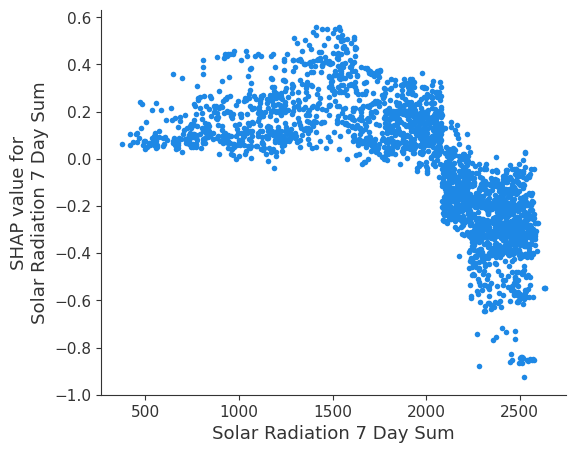

In [41]:
shap.dependence_plot(
    "Solar Radiation 7 Day Sum",
    shap_class,
    X_xgb,
    interaction_index=None
)

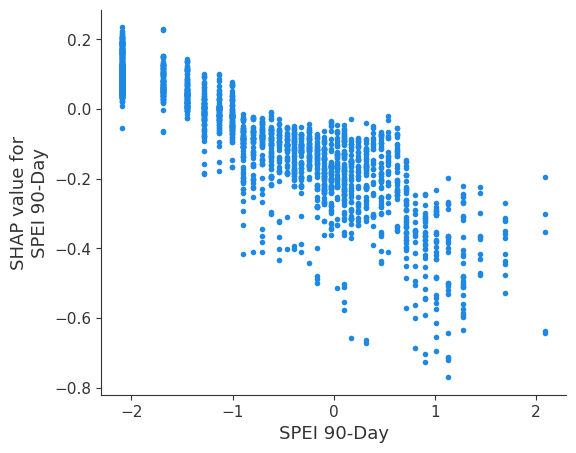

In [42]:
shap.dependence_plot(
    "SPEI 90-Day",
    shap_class,
    X_xgb,
    interaction_index=None
)

## Set Ablation

In [16]:
Ablation_single_column = ablation(models, X, y, feature_sets, best_strategy, single_set = False)

Testing XGB: Water Demand



KeyboardInterrupt



In [ ]:
# Assume your table is in a DataFrame called df
# Filter out the full runs
full_model = Ablation_single_column[Ablation_single_column['Test Set'] == 'Full'][['Model', 'Macro F1']].rename(columns={'Macro F1': 'Full Macro F1'})

# Merge back to the main dataframe on 'Model'
pivot_ablation = Ablation_single_column.merge(full_model, on='Model', how='left')

# Drop columns you don’t need for now
pivot_ablation = pivot_ablation.drop(columns=['Weighted F1', 'High Risk Recall'])

largest_drops = pivot_ablation[pivot_ablation['Macro F1 Percent Difference'] > .2]
smallest_drops = pivot_ablation[pivot_ablation['Macro F1 Percent Difference'] < 0]

In [ ]:
largest_drops

In [ ]:
smallest_drops

In [ ]:
Ablation_single_column